# 02 - Pretprocesiranje podataka

U ovoj svesci pripremamo podatke za sve modele u projektu. Radimo sledeće:

1. izbacujemo atribute koji bi doveli do curenja informacija
2. kodiramo nominalne atribute
3. delimo podatke na skupove za treniranje, validaciju i testiranje
4. pravimo trivijalnu osnovu sa kojom ćemo porediti sve modele

Pripremljene podatke čuvamo u datoteku koju naredne sveske učitavaju, tako da svi
modeli koriste iste atribute i istu podelu.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn import linear_model
from sklearn import preprocessing
from sklearn import model_selection
from sklearn import metrics

np.random.seed(7)

# Učitavanje podataka

In [2]:
sat = pd.read_csv('../data/hour.csv')
sat.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
sat.shape

(17379, 17)

# Curenje informacija

U svesci 01 smo videli da je cnt tačno zbir atributa casual i  registered. Ako ta dva atributa ostanu u ulazu, model ne uči ništa, samo sabira dva broja koja smo mu dali. Proveravamo to na linearnoj regresiji.

In [4]:
x_curenje = sat[['casual', 'registered', 'temp', 'hr']].astype(float)
y = sat['cnt'].values

model = linear_model.LinearRegression()
model.fit(x_curenje, y)

print('R2 sa atributima casual i registered:', round(metrics.r2_score(y, model.predict(x_curenje)), 6))

R2 sa atributima casual i registered: 1.0


Koeficijent determinacije je tačno jedan. Model je savršen i potpuno beskoristan, jer u trenutku predviđanja ne možemo znati koliko je bilo povremenih i registrovanih korisnika, kao što ne znamo ni ukupan broj.

Pored ta dva atributa izbacujemo i:

- instant, redni broj zapisa, koji raste sa vremenom i model bi preko njega
  mogao da nauči da kasniji zapisi imaju veće vrednosti
- dteday, datum kao tekst, jer tu informaciju već imamo kroz godinu, mesec
  i dan u nedelji
- atemp, jer je njegova korelacija sa temp 0.99 pa nosi istu
  informaciju

# Kodiranje atributa

Preostale atribute delimo u tri grupe.

Numerički atributi temp, hum i windspeed su već svedeni na opseg od 0 do 1, pa ih uzimamo kakvi jesu. Binarni atributi yr,
holiday i workingday su već nule i jedinice.

Nominalni atributi season, weathersit, hr, mnth i weekday su zapisani brojevima, ali redosled tih brojeva nema smisla za model. Sat 8 i sat 17 imaju najveću potražnju, a sat 12 između njih ima manju, pa se to jednim koeficijentom ne može opisati.

Zato ih kodiramo na način koji je na predavanjima prikazan kao kodiranje kategoričkih promenljivih (dummy coding): svaka kategorija dobija svoju kolonu sa nulom ili jedinicom, a jedna kategorija ostaje kao podrazumevana, sa nulama u svim kolonama. U pandas biblioteci to radi funkcija get_dummies.

In [5]:
NOMINALNI = ['season', 'weathersit', 'hr', 'mnth', 'weekday']
NUMERICKI = ['temp', 'hum', 'windspeed']
BINARNI   = ['yr', 'holiday', 'workingday']
CILJ      = 'cnt'

In [6]:
X = pd.concat([
    sat[NUMERICKI + BINARNI],
    pd.get_dummies(sat[NOMINALNI].astype(str), drop_first=True).astype(float)
], axis=1)

y = sat[CILJ].values

print('oblik matrice atributa:', X.shape)

oblik matrice atributa: (17379, 52)


In [7]:
X.head()

,temp,hum,windspeed,yr,holiday,workingday,season_2,season_3,season_4,weathersit_2,...,mnth_6,mnth_7,mnth_8,mnth_9,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
0,0.24,0.81,0.0,0,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.22,0.80,0.0,0,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.22,0.80,0.0,0,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.24,0.75,0.0,0,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.24,0.75,0.0,0,0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Dobili smo 52 kolone za 17379 instanci, dakle više od 330 instanci po koloni, što je sasvim dovoljno.

Parametar drop_first=True izbacuje po jednu kategoriju iz svakog atributa i ona postaje podrazumevana, kao kategorija sa svim nulama u primeru sa predavanja.

Ako znamo da nije nijedno od preostala tri godišnja doba, znamo da je ono četvrto, pa bi ta kolona bila potpuno određena ostalima. Takva zavisnost smeta linearnim modelima, jer bi zbir svih kolona jednog atributa uvek bio jedan, isto kao slobodan član.

Jedna kolona zaslužuje napomenu. Kategorija 4 atributa weathersit, jaka kiša ili sneg, javlja se samo tri puta u celom skupu, jednom u 2011. i dvaput u 2012. Kolonu zadržavamo radi jednostavnosti, ali iz nje nijedan model ne može mnogo da nauči.

# Podela podataka

Podatke delimo na tri skupa. Na skupu za treniranje model uči parametre, na skupu za validaciju biramo metaparametre, a skup za testiranje koristimo jednom, na kraju, za ocenu konačnog modela.

Konačni model se uvek obučava na uniji skupova za treniranje i validaciju: kod modela sa metaparametrima tek pošto su metaparametri izabrani, a kod modela koji metaparametre nemaju (trivijalna osnova, linearna regresija) odmah, jer skup za validaciju kod njih nema šta da bira.

Podaci su vremenski niz, pa proveravamo koliko su susedni sati slični.

In [8]:
print('korelacija sa prethodnim satom:', round(sat['cnt'].autocorr(lag=1), 3))
print('korelacija sa istim satom prethodnog dana:', round(sat['cnt'].autocorr(lag=24), 3))

korelacija sa prethodnim satom: 0.844
korelacija sa istim satom prethodnog dana: 0.816


Korelacija susednih sati je 0.84. Ako bismo podatke delili nasumično, sat 14 nekog dana bi mogao otići u trening, a sat 15 istog dana u test. Model tada ne bi predviđao nego interpolirao između dve gotovo iste vrednosti, pa rezultat izgleda bolje nego što jeste.

Zato delimo hronološki: 2011. godina ide u treniranje i validaciju, a 2012. u testiranje. Unutar 2011. prvih 80 posto vremena je trening, a poslednjih 20 posto validacija.

In [9]:
je_2011 = (sat['yr'] == 0).values
indeksi_2011 = np.where(je_2011)[0]
granica = indeksi_2011[int(0.8 * len(indeksi_2011))]

h_trening = je_2011 & (np.arange(len(sat)) < granica)
h_validacija = je_2011 & (np.arange(len(sat)) >= granica)
h_test = (sat['yr'] == 1).values

print('hronološka podela')
print('trening:   ', h_trening.sum())
print('validacija:', h_validacija.sum())
print('test:      ', h_test.sum())

hronološka podela
trening:    6916
validacija: 1729
test:       8734


Napravljena je i nasumična podela, sa skupovima iste veličine, da bismo u narednim sveskama izmerili koliko ona precenjuje rezultat. Pošto su skupovi iste veličine, jedina razlika između dve podele je način deljenja.

In [10]:
svi_indeksi = np.arange(len(sat))

ostatak, indeksi_test = model_selection.train_test_split(svi_indeksi, test_size=h_test.sum(), random_state=7)
indeksi_trening, indeksi_validacija = model_selection.train_test_split(ostatak, test_size=h_validacija.sum(), random_state=7)

n_trening = np.zeros(len(sat), dtype=bool)
n_trening[indeksi_trening] = True

n_validacija = np.zeros(len(sat), dtype=bool)
n_validacija[indeksi_validacija] = True

n_test = np.zeros(len(sat), dtype=bool)
n_test[indeksi_test] = True

print('nasumična podela')
print('trening:   ', n_trening.sum())
print('validacija:', n_validacija.sum())
print('test:      ', n_test.sum())

nasumična podela
trening:    6916
validacija: 1729
test:       8734


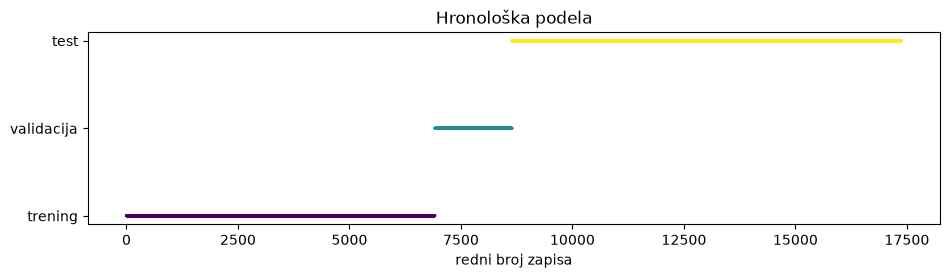

In [11]:
plt.figure(figsize=(11, 2.5))
skup = np.where(h_trening, 0, np.where(h_validacija, 1, 2))
plt.scatter(range(len(sat)), skup, c=skup, s=1)
plt.yticks([0, 1, 2], ['trening', 'validacija', 'test'])
plt.xlabel('redni broj zapisa')
plt.title('Hronološka podela')
plt.show()

In [12]:
print('prosek broja iznajmljivanja po skupu')
print('trening:   ', round(y[h_trening].mean(), 1))
print('validacija:', round(y[h_validacija].mean(), 1))
print('test:      ', round(y[h_test].mean(), 1))

prosek broja iznajmljivanja po skupu
trening:    146.5
validacija: 133.1
test:       234.7


Prosek na skupu za testiranje je 235 bicikala po satu, a na skupu za treniranje 147. To nije greška u podeli, nego posledica rasta sistema koji smo videli u svesci 01. Svaki model naučen na 2011. godini će zato potcenjivati 2012. godinu. Nasumična podela taj problem sakriva, jer u njoj obe godine ravnomerno ulaze u sve skupove.

# Standardizacija

Statistike za standardizaciju se računaju samo na skupu za treniranje, a zatim se primenjuju na ostale skupove. Ako bi se računale na celom skupu, u trening bi ušla informacija o podacima za testiranje. 

In [13]:
scaler = preprocessing.StandardScaler()
scaler.fit(X[h_trening])

x_train = scaler.transform(X[h_trening])
x_test = scaler.transform(X[h_test])

print('prosek temperature na treningu posle standardizacije:', round(x_train[:, 0].mean(), 3))
print('prosek temperature na testu posle standardizacije:   ', round(x_test[:, 0].mean(), 3))

prosek temperature na treningu posle standardizacije: 0.0
prosek temperature na testu posle standardizacije:    -0.069


Na treningu je prosek nula, što je i bilo očekivano. Na testu nije nula, jer skaler nije video skup za testiranje. Svaka naredna sveska će praviti svoj skaler na isti način, samo na podacima koji ulaze u obučavanje.

# Trivijalna osnova

Pre bilo kog modela pravimo osnovu sa kojom ćemo porediti rezultate. Ona za svaki par sata i tipa dana predviđa prosek koji je videla na podacima za obučavanje, dakle na uniji skupova za treniranje i validaciju, po pravilu iz odeljka o podeli. Bez nje ne znamo da li je greška nekog modela dobra ili loša.

In [14]:
def trivijalna_osnova(maska_ucenja, maska_procene):
    prosek = sat[maska_ucenja].groupby(['hr', 'workingday'])['cnt'].mean()
    kljucevi = sat[maska_procene].set_index(['hr', 'workingday']).index
    return kljucevi.map(prosek).to_numpy(dtype=float)

Sve modele u projektu ocenjujemo istim merama: srednjom apsolutnom greškom, korenom srednje kvadratne greške i koeficijentom determinacije (R2). Računamo i prosečnu razliku predviđene i stvarne vrednosti, koja pokazuje da li model sistematski potcenjuje ili precenjuje potražnju.

In [15]:
def oceni(y_stvarno, y_predvidjeno, naziv):
    mae = metrics.mean_absolute_error(y_stvarno, y_predvidjeno)
    rmse = np.sqrt(metrics.mean_squared_error(y_stvarno, y_predvidjeno))
    r2 = metrics.r2_score(y_stvarno, y_predvidjeno)
    odstupanje = np.mean(y_predvidjeno - y_stvarno)
    print('%-38s MAE %6.1f  RMSE %6.1f  R2 %6.3f  odstupanje %+7.1f'
          % (naziv, mae, rmse, r2, odstupanje))
    return {'model': naziv, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'odstupanje': odstupanje}

In [16]:
osnova_h = trivijalna_osnova(h_trening | h_validacija, h_test)
osnova_n = trivijalna_osnova(n_trening | n_validacija, n_test)

oceni(y[h_test], osnova_h, 'trivijalna osnova, hronološka')
oceni(y[n_test], osnova_n, 'trivijalna osnova, nasumična')
print()

trivijalna osnova, hronološka          MAE  108.5  RMSE  157.1  R2  0.435  odstupanje   -91.9
trivijalna osnova, nasumična           MAE   73.4  RMSE  111.1  R2  0.625  odstupanje    +2.0



Ista osnova daje sasvim različitu sliku na dve podele. Na hronološkoj podeli greška je
oko 108 bicikala po satu, a odstupanje -92, dakle osnova naučena na 2011. potcenjuje 2012.
za oko devedeset bicikala po satu. Na nasumičnoj podeli odstupanje je blizu nule, jer su
obe godine ravnomerno raspoređene.

Svaki model u narednim sveskama treba da bude bolji od ovih brojeva da bi imao smisla.

# Čuvanje pripremljenih podataka

Čuvamo matricu atributa, ciljnu promenljivu i obe podele. Naredne sveske učitavaju ovu
datoteku i ne menjaju podelu.

In [17]:
paket = {
    'X': X,
    'y': y,
    'kolone': list(X.columns),
    'h_trening': h_trening,
    'h_validacija': h_validacija,
    'h_test': h_test,
    'n_trening': n_trening,
    'n_validacija': n_validacija,
    'n_test': n_test,
    'seed': 7
}

joblib.dump(paket, '../data/pripremljeno.joblib')

print('sačuvano')

sačuvano


# Zaključci

1. Atributi casual i registered dovode do curenja informacija,
   sa njima u ulazu koeficijent determinacije je tačno jedan. Izbačeni su, zajedno sa
   instant, dteday i atemp.

2. Nominalni atributi su kodirani kao kategoričke promenljive, po jedna kolona za svaku kategoriju i jedna podrazumevana, čime je dobijeno     52 kolone.

3. Podela je hronološka, 2011. za treniranje i validaciju, 2012. za testiranje.
   Nasumična podela iste veličine je napravljena samo za poređenje.

4. Trivijalna osnova, prosek po satu i tipu dana, ima grešku od oko 108 bicikala po satu
   na hronološkoj podeli i potcenjuje 2012. godinu za oko devedeset bicikala.